# Enhancing K-means Clustering with Association Rule Mining

In [670]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import mode


## Load data

In [671]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/mobile_price.csv')
print(df.shape)
df.head()


(2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## EDA

In [672]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


## Preprocessing

In [673]:
# Cheak N/A value
print(df.isnull().sum())
print((df < 0).sum())

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


## StandardScaler (Normalization)

In [674]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

X = df.drop('price_range',axis=1) 
y = df['price_range'] 

# 1 only normalize continuous column
## Find column with more uninque value
print(X.nunique())
# continuous_features = [col for col in X.columns if X[col].nunique() > 10]
# scaler = StandardScaler()
# X[continuous_features] = scaler.fit_transform(X[continuous_features])

#2 normalize all
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

battery_power    1094
blue                2
clock_speed        26
dual_sim            2
fc                 20
four_g              2
int_memory         63
m_dep              10
mobile_wt         121
n_cores             8
pc                 21
px_height        1137
px_width         1109
ram              1562
sc_h               15
sc_w               19
talk_time          19
three_g             2
touch_screen        2
wifi                2
dtype: int64


In [675]:
## Correlation Analysis

In [676]:
from sklearn.feature_selection import r_regression

r_scores = r_regression(X, y) # output: array with no column names

ranking_corr = pd.DataFrame({
    'Feature': X.columns,
    'Correlation': r_scores,
}).sort_values(by='Correlation', ascending=False)

ranking_corr

,Feature,Correlation
13,ram,0.917046
0,battery_power,0.200723
12,px_width,0.165818
11,px_height,0.148858
6,int_memory,0.044435
15,sc_w,0.038711
10,pc,0.033599
17,three_g,0.023611
14,sc_h,0.022986
4,fc,0.021998


## Original K-means Clustering

In [677]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics.cluster import adjusted_rand_score

seeds = [0, 10, 42, 100, 999]

def run_kmeans(data, target, seeds):
    metrics = []
    for s in seeds:
        km = KMeans(n_clusters=4, random_state=s, n_init=10)
        pred = km.fit_predict(data)
        
        # Calculate adjusted rand index
        ari = adjusted_rand_score(target, pred)

        # Cluster-to-Label Mapping
        map_labels = np.zeros_like(pred)
        for i in range(4):
            mask = (pred == i) 
            if np.any(mask): # predict results == 0/1/2/3
                map_labels[mask] = mode(target[mask])[0] # [0] mode; [1] count
        
        metrics.append([
            accuracy_score(target, map_labels),
            precision_score(target, map_labels, average='macro', zero_division=0),
            recall_score(target, map_labels, average='macro',zero_division=0),
            f1_score(target, map_labels, average='macro',zero_division=0), # zero_division=0 to avoid waring displys 
            ari
        ])
        
    result = np.mean(np.array(metrics), axis=0)
    return result

def get_performance (accuracy, precision, recall, f1, ari):
    print("== Performance ==")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ARI:       {ari:.4f}")


accuracy, precision, recall, f1, ari = run_kmeans(X_scaled, y, seeds)
get_performance(accuracy, precision, recall, f1, ari)


== Performance ==
Accuracy:  0.3002
Precision: 0.2288
Recall:    0.3002
F1-score:  0.2471
ARI:       0.0058


## Association Rule Mining
1. Binning
2. Apriori Algorithm
3. Association Rules Mining (Target: price range)
4. Weight Calculation
5. Apply weights

### 1. Binning

In [678]:
# X = df.drop('price_range', axis=1) 
# y = df['price_range']
X_bin=X.copy()

for col in X_bin.columns:
    unique_count = X_bin[col].nunique()
    
    if unique_count <= 2:
        # --- Binary variable ---
        # 0 -> "col_No" / 1 to "col_Yes"
        X_bin[col] = X_bin[col].map({
            1: "Yes", 
            0: "No"
        })
    else:
        # --- Continuous variable ---
        # seperate into 3 levels, duplicates='drop' avoid failure
        X_bin[col] = pd.qcut(
            X_bin[col], 
            q=3, 
            labels=['Low', 'Medium', 'High'], 
            # duplicates='drop'
        )

X_bin['price_range'] = y
X_dummy = pd.get_dummies(X_bin, columns=X_bin.columns)

### 2. Apriori Algorithm

In [679]:
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
# Apriori
frequent_itemsets = apriori(X_dummy, min_support=0.06, use_colnames=True)
print(frequent_itemsets.sort_values(by='support', ascending=False))
# FPgrowth
frequent_itemsets_2 = fpgrowth(X_dummy, min_support=0.06, use_colnames=True)
print(frequent_itemsets_2.sort_values(by='support', ascending=False))

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=2) # must be higher than 1, lower than 1 means negative correlation


      support                                           itemsets
49     0.7615                           frozenset({three_g_Yes})
782    0.5215               frozenset({four_g_Yes, three_g_Yes})
14     0.5215                            frozenset({four_g_Yes})
9      0.5095                          frozenset({dual_sim_Yes})
53     0.5070                              frozenset({wifi_Yes})
...       ...                                                ...
7691   0.0600  frozenset({wifi_Yes, touch_screen_Yes, price_r...
4259   0.0600  frozenset({talk_time_Low, dual_sim_No, px_heig...
1801   0.0600  frozenset({touch_screen_Yes, sc_h_Low, battery...
3990   0.0600        frozenset({dual_sim_No, sc_h_Low, fc_High})
9530   0.0600  frozenset({price_range_3, touch_screen_No, fou...

[9534 rows x 2 columns]
      support                                           itemsets
21     0.7615                           frozenset({three_g_Yes})
3238   0.5215               frozenset({four_g_Yes, three_g_Yes})


### 3. Association Rules Mining (Target: price range)

In [680]:
# Filter rules with 'price_range' = consequents & 'price_range'!= antecedents
price_rules = rules[
    rules['consequents'].apply(lambda x: any('price_range' in str(i) for i in x)) & 
    rules['antecedents'].apply(lambda x: not any('price_range' in str(i) for i in x))]
print(price_rules['lift'].count())
price_rules = price_rules.sort_values(by='lift', ascending=False)
print(price_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

742
                                            antecedents  \
1118                       frozenset({fc_Low, ram_Low})   
1120                       frozenset({ram_Low, pc_Low})   
1645  frozenset({three_g_Yes, battery_power_High, ra...   
1643  frozenset({four_g_Yes, battery_power_High, ram...   
1855                   frozenset({four_g_Yes, ram_Low})   
1849         frozenset({ram_Low, three_g_Yes, wifi_No})   
1883  frozenset({four_g_Yes, touch_screen_Yes, ram_H...   
1770    frozenset({ram_Low, three_g_Yes, dual_sim_Yes})   
1889                  frozenset({four_g_Yes, ram_High})   
1714                  frozenset({four_g_Yes, ram_High})   

                                            consequents  support  confidence  \
1118                 frozenset({pc_Low, price_range_0})   0.0615    0.484252   
1120                 frozenset({fc_Low, price_range_0})   0.0615    0.478599   
1645             frozenset({four_g_Yes, price_range_3})   0.0605    0.687500   
1643            frozenset(

In [681]:
# Weight calculation - MAX method
max_lift = {}
for index, row in price_rules.iterrows():
    for item in row['antecedents']: # get the reason list
        feature_split = item.split('_') # list seperate by _
        feature_name = "_".join(feature_split[:-1]) # get the last item and recombine the remain item
        
        # find maximum
        current_lift = row['lift']
        if feature_name not in max_lift or current_lift > max_lift[feature_name]:
            max_lift[feature_name] = current_lift

## Sorting
sorted_impact = sorted(max_lift.items(), key=lambda x: x[1], reverse=True)
print("== Max Lift ==")
for feature, lift in sorted_impact:
    print(f"{feature}: {lift:.2f}")

== Max Lift ==
fc: 5.10
ram: 5.10
pc: 5.09
three_g: 5.00
battery_power: 5.00
four_g: 4.76
wifi: 4.23
touch_screen: 4.22
dual_sim: 4.19
blue: 4.05
px_height: 3.84
px_width: 3.62
sc_w: 3.28
mobile_wt: 3.24
m_dep: 3.17
sc_h: 3.17
talk_time: 3.16
n_cores: 3.13
int_memory: 3.04
clock_speed: 3.03


In [682]:
# Weight calculation - MEAN method

mean_lifts_collection = {}

for index, row in price_rules.iterrows():
    for item in row['antecedents']:
        feature_split = item.split('_')
        feature_name = "_".join(feature_split[:-1])
        
        if feature_name not in mean_lifts_collection:
            mean_lifts_collection[feature_name] = []

        mean_lifts_collection[feature_name].append(row['lift']) # Save lift value to list

# Calculate mean value
mean_lift = {}
for feat, lifts in mean_lifts_collection.items():
    mean_lift[feat] = sum(lifts) / len(lifts)

# Impute weight if didn't used in rules (default weight: 1.0)
# all_features_weights = {col: final_mean_weights.get(col, 1.0) for col in X.columns}

# Sorting
weight_series_mean = pd.Series(mean_lift).sort_values(ascending=False)
print("=== Mean Lift ===")
print(weight_series_mean)

=== Mean Lift ===
battery_power    3.406143
four_g           3.258786
px_width         3.109481
fc               3.090227
three_g          3.083700
pc               3.077421
wifi             3.026877
px_height        3.013051
blue             3.001555
dual_sim         2.996657
ram              2.985091
touch_screen     2.984342
sc_w             2.966782
mobile_wt        2.937832
talk_time        2.933140
int_memory       2.921697
m_dep            2.908516
clock_speed      2.904835
sc_h             2.848396
n_cores          2.816694
dtype: float64


### Apply weights to get weighted features

In [683]:
mean_weights_array = np.array([mean_lift[col] for col in X.columns])
max_weights_array = np.array([max_lift[col] for col in X.columns])
mean_X_weighted = X_scaled * mean_weights_array
max_X_weighted = X_scaled * max_weights_array

# According to correlation analysis, enhance the weight of 'ram
max_X_weighted['ram'] = max_X_weighted['ram']*10
mean_X_weighted['ram'] = mean_X_weighted['ram']*10

## Performance Evaluation

In [684]:
# Improved K-means by mean lift
accuracy_mean, precision_mean, recall_mean, f1_mean, ari_mean = run_kmeans(mean_X_weighted, y, seeds)
get_performance(accuracy_mean, precision_mean, recall_mean, f1_mean, ari_mean)

== Performance ==
Accuracy:  0.7517
Precision: 0.7559
Recall:    0.7517
F1-score:  0.7528
ARI:       0.4871


In [685]:
# Improved K-means by max lift
accuracy_max, precision_max, recall_max, f1_max, ari_max = run_kmeans(max_X_weighted, y, seeds)
get_performance(accuracy_max, precision_max, recall_max, f1_max, ari_max )

== Performance ==
Accuracy:  0.7519
Precision: 0.7558
Recall:    0.7519
F1-score:  0.7530
ARI:       0.4870


## Results

== Original Performance ==

Accuracy:  0.3002
Precision: 0.2288
Recall:    0.3002
F1-score:  0.2471
ARI:       0.0058

== Weighted Performance (mean) ==

Accuracy:  0.7517
Precision: 0.7559
Recall:    0.7517
F1-score:  0.7528
ARI:       0.4871

== Weighted Performance (Max) ==

Accuracy:  0.7519
Precision: 0.7558
Recall:    0.7519
F1-score:  0.7530
ARI:       0.4870




## Difference before/after weighting

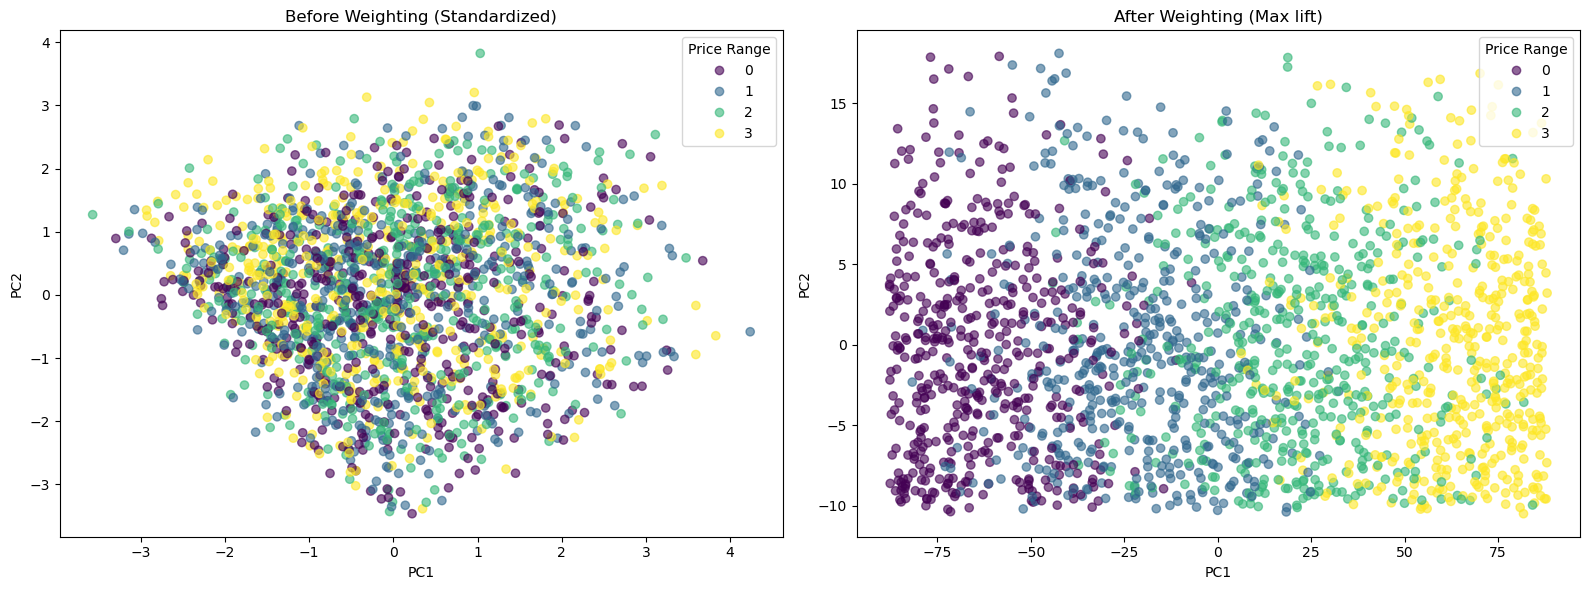

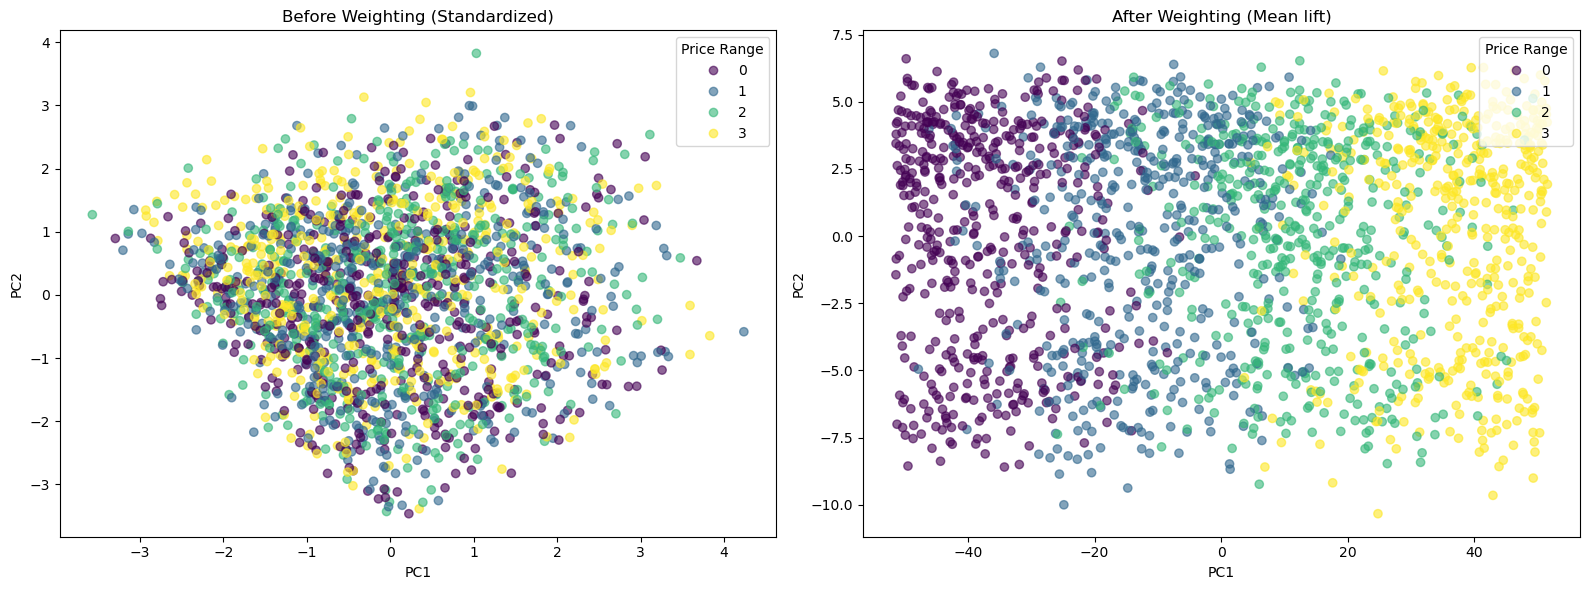

In [686]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def plot_pca_comparison(X_before, X_after, labels, title_label,title_suffix=""):
    pca = PCA(n_components=2)
    
    X_pca_before = pca.fit_transform(X_before)
    X_pca_after = pca.fit_transform(X_after)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pic 1：Before Weighting
    scatter1 = ax1.scatter(X_pca_before[:, 0], X_pca_before[:, 1], c=labels, cmap='viridis', alpha=0.6)
    ax1.set_title(f'Before Weighting (Standardized)')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    
    # Pic 2：After Weighting
    scatter2 = ax2.scatter(X_pca_after[:, 0], X_pca_after[:, 1], c=labels, cmap='viridis', alpha=0.6)
    ax2.set_title(f'After Weighting {title_label}')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    
    # plt.colorbar(scatter2, ax=ax2, ticks=range(4), label='Price Range')
    handles, _ = scatter2.legend_elements()
    class_names=['0','1','2','3']
    ax1.legend(handles, class_names, title="Price Range", loc="upper right")
    ax2.legend(handles, class_names, title="Price Range", loc="upper right")
    plt.tight_layout()
    plt.show()

plot_pca_comparison(X_scaled, max_X_weighted, y, '(Max lift)')
plot_pca_comparison(X_scaled, mean_X_weighted, y, '(Mean lift)')


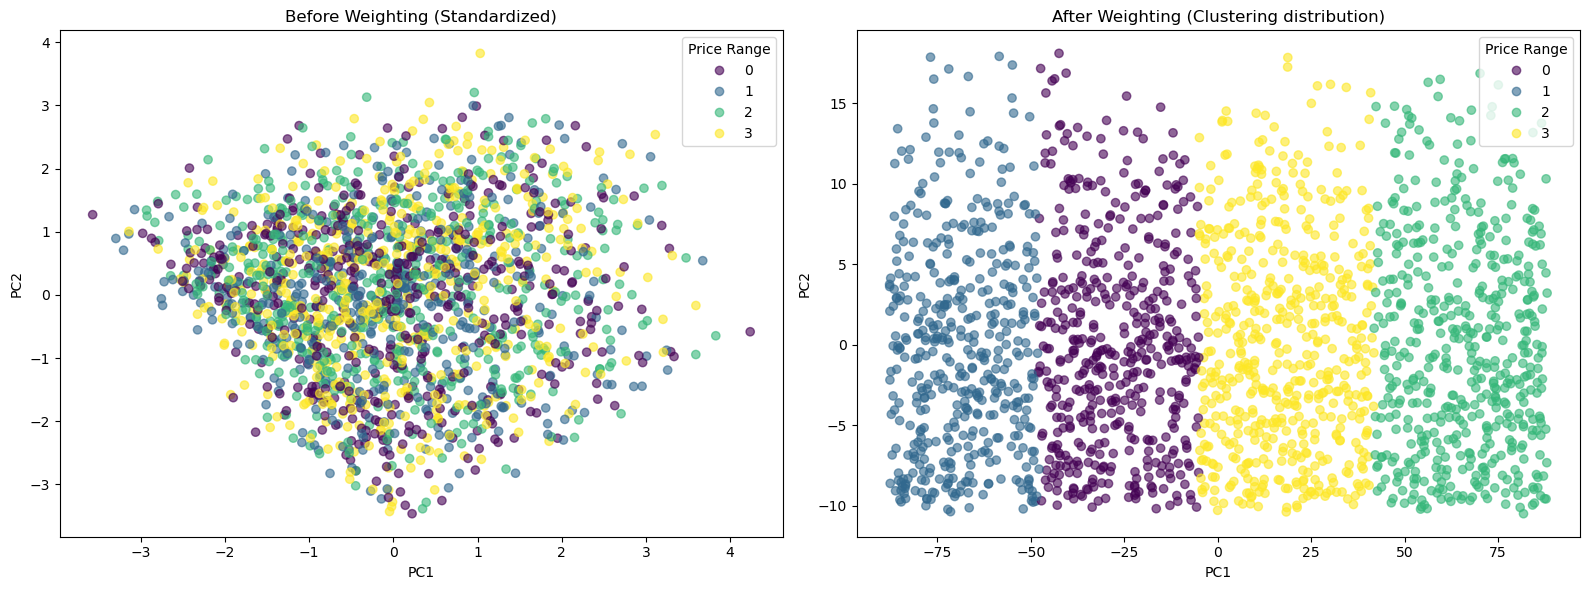

In [690]:
kmeans = KMeans(n_clusters=4, random_state=99)
kmeans.fit(mean_X_weighted)
plot_pca_comparison(X_scaled, max_X_weighted, kmeans.labels_,'(Clustering distribution)')